# Time Series 

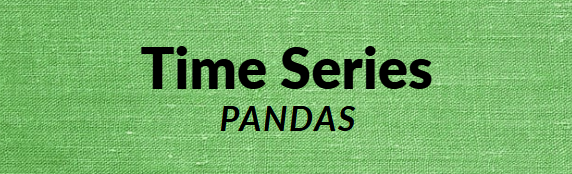

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Converting to a Time Series Index](#convert)
3. [Indexing and Slicing](#indexing)
4. [Resampling](#resampling)
6. [Moving Averages and Shifting](#shift)
7. [Date ranges](#date)
8. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction</i></b>
    <a id="introduction"></a></div>

time series are samples of values collected over time, usually at regular intervals.
For example: economic data, demographic data, meteorological data, security logs, activity records, etc.

The Pandas library handles time series using the index: a date (datetime).
Python datetime documentation: https://docs.python.org/3/library/datetime.html

The DataFrame index is the main way to access values, so using a datetime index simplifies filtering, selection, interpolation, and more.

Pandas time series documentation: [TimeSeries](https://pandas.pydata.org/docs/user_guide/timeseries.html)

In [28]:
import pandas as pd

We will use the following dataset:

In [29]:
df = pd.read_csv("rdu-weather-history.csv",sep=";")  
df.head()

,date,temperaturemin,temperaturemax,precipitation,snowfall,snowdepth,avgwindspeed,fastest2minwinddir,fastest2minwindspeed,fastest5secwinddir,...,drizzle,snow,freezingrain,smokehaze,thunder,highwind,hail,blowingsnow,dust,freezingfog
0,2015-04-08,62.1,84.0,0.00,0.0,0.0,5.82,40.0,29.97,30.0,...,No,No,No,Yes,No,No,No,No,No,No
1,2015-04-20,63.0,78.1,0.28,0.0,0.0,11.86,180.0,21.92,170.0,...,No,No,No,No,Yes,No,No,No,No,No
2,2015-04-26,45.0,54.0,0.02,0.0,0.0,5.82,50.0,12.97,40.0,...,No,No,No,No,No,No,No,No,No,No
3,2015-04-28,39.0,69.1,0.00,0.0,0.0,2.68,40.0,12.08,40.0,...,No,No,No,No,No,No,No,No,No,No
4,2015-05-03,46.9,79.0,0.00,0.0,0.0,2.68,200.0,12.08,210.0,...,No,No,No,No,No,No,No,No,No,No


This dataset contains weather information such as: temperature, precipitation, snowfall, wind speed, weather conditions, etc. First, let's take a look at the date column:

In [30]:
type(df.date[0])

str

<div class="alert alert-warning">
    <b> II. <i>Converting to a Time Series Index</i></b>
    <a id="convert"></a>
</div>

The date column is initially just text (strings), not actual dates. That means Pandas cannot treat it as a time series yet.
To work properly with time-based data (filtering by year, resampling, etc.), we need to convert that column into a datetime index. To do so, we need to import the class ``DatetimeIndex``:

In [31]:
from pandas import DatetimeIndex

Then, we convert the date column into a real datetime object and assign it as the index of the DataFrame. After this step, the DataFrame is no longer indexed by numbers (0, 1, 2…), but by actual dates.

In [32]:
df.index = DatetimeIndex(df["date"])
df.sort_index(inplace=True)
df.head()

,date,temperaturemin,temperaturemax,precipitation,snowfall,snowdepth,avgwindspeed,fastest2minwinddir,fastest2minwindspeed,fastest5secwinddir,...,drizzle,snow,freezingrain,smokehaze,thunder,highwind,hail,blowingsnow,dust,freezingfog
date,,,,,,,,,,,,,,,,,,,,,
2007-01-01,2007-01-01,48.9,68.0,0.45,0.0,0.0,12.75,190.0,25.05,180.0,...,No,No,No,No,No,No,No,No,No,No
2007-01-02,2007-01-02,32.0,55.9,0.00,0.0,0.0,3.13,320.0,12.97,330.0,...,No,No,No,No,No,No,No,No,No,No
2007-01-03,2007-01-03,28.9,62.1,0.00,0.0,0.0,2.24,220.0,14.09,220.0,...,No,No,No,No,No,No,No,No,No,No
2007-01-04,2007-01-04,46.0,69.1,0.00,0.0,0.0,4.47,220.0,14.09,230.0,...,No,No,No,No,No,No,No,No,No,No
2007-01-05,2007-01-05,57.0,72.0,0.86,0.0,0.0,8.05,190.0,21.03,190.0,...,No,No,No,No,No,No,No,No,No,No


Once the date is part of the index, the original "date" column is redundant.
So we remove it to keep the dataset clean.

In [33]:
df.drop(columns="date",inplace=True)

<div class="alert alert-warning">
    <b> III. <i>Indexing and Slicing</i></b>
    <a id="indexing"></a>
</div>

We can access time related components easily:

In [34]:
print(df.index.day)
print(df.index.weekday)

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
      dtype='int32', name='date', length=4557)
Index([0, 1, 2, 3, 4, 5, 6, 0, 1, 2,
       ...
       4, 5, 6, 0, 1, 2, 3, 4, 5, 6],
      dtype='int32', name='date', length=4557)


Filter business days (Monday–Friday):

In [35]:
business_days = df[df.index.weekday < 5]
business_days[["temperaturemax"]].head(8)

,temperaturemax
date,
2007-01-01,68.0
2007-01-02,55.9
2007-01-03,62.1
2007-01-04,69.1
2007-01-05,72.0
2007-01-08,66.9
2007-01-09,55.0
2007-01-10,44.1


__Select by date ranges__

In [36]:
df.loc["2014"]              # full year
df.loc["2014-01-03"]        # specific day
df.loc["2014-01":"2016-06"] # range

,temperaturemin,temperaturemax,precipitation,snowfall,snowdepth,avgwindspeed,fastest2minwinddir,fastest2minwindspeed,fastest5secwinddir,fastest5secwindspeed,...,drizzle,snow,freezingrain,smokehaze,thunder,highwind,hail,blowingsnow,dust,freezingfog
date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,29.1,51.1,0.00,0.0,0.0,2.46,200.0,8.95,210.0,12.97,...,No,No,No,No,No,No,No,No,No,No
2014-01-02,37.0,48.9,0.33,0.0,0.0,2.68,310.0,12.97,320.0,21.92,...,No,No,No,No,No,No,No,No,No,No
2014-01-03,22.1,43.0,0.00,0.0,0.0,7.38,300.0,21.92,310.0,31.99,...,No,No,No,No,No,No,No,No,No,No
2014-01-04,19.2,37.9,0.00,0.0,0.0,2.24,120.0,8.05,120.0,12.97,...,No,No,No,No,No,No,No,No,No,No
2014-01-05,37.0,62.1,0.00,0.0,0.0,4.92,180.0,16.11,180.0,21.03,...,No,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-06-26,64.0,84.9,0.00,0.0,0.0,3.80,80.0,12.08,80.0,17.00,...,No,No,No,No,No,No,No,No,No,No
2016-06-27,64.9,90.0,0.00,0.0,0.0,4.70,220.0,12.97,150.0,16.11,...,No,No,No,No,No,No,No,No,No,No
2016-06-28,71.1,78.1,1.25,0.0,0.0,4.70,230.0,12.08,200.0,17.00,...,No,No,No,No,No,No,No,No,No,No


In [37]:
df.loc["2018-01-01":"2018-01-15", ["temperaturemin", "temperaturemax"]].head()

,temperaturemin,temperaturemax
date,,
2018-01-01,13.1,28.2
2018-01-02,12.2,32.0
2018-01-03,9.1,32.0
2018-01-04,18.1,30.2
2018-01-05,12.2,31.1


Or do basic analysis:

In [38]:
df.loc["2015"].temperaturemin.mean()

51.70246575342466

In [39]:
df.loc["2015"].temperaturemin.min() > df.loc["2016"].temperaturemin.min()

False

<div class="alert alert-warning">
    <b> IV. <i>Resampling</i></b>
    <a id="resampling"></a>
</div>

Resampling means changing the frequency of your time series data. 
You can find the documentation here: [Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html)

__Downsampling__
We can start by reducing the frequency (dopwnsampling). We with many data points (e.g., daily) and reduce them into fewer (e.g., monthly).

In [40]:
monthly_avg = df[["temperaturemin", "temperaturemax"]].resample("ME").mean()
print(monthly_avg.head())


            temperaturemin  temperaturemax
date                                      
2007-01-31       34.922581       55.535484
2007-02-28       30.067857       51.532143
2007-03-31       42.161290       69.541935
2007-04-30       47.593333       72.243333
2007-05-31       56.041935       80.287097


We can see other examples like reducing them monthly or yearly. It is like performing ``groupby`` but for time.

In [41]:
weekly_avg = df[["temperaturemin", "temperaturemax"]].resample("W").mean()
quarterly_avg = df[["temperaturemin", "temperaturemax"]].resample("QE").mean()

We can also perform aggregations:

In [42]:
monthly_stats = df[["temperaturemax", "precipitation"]].resample("ME").agg({
    "temperaturemax": ["mean", "max", "min"],
    "precipitation": "sum"
})
print(monthly_stats.head())

           temperaturemax             precipitation
                     mean   max   min           sum
date                                               
2007-01-31      55.535484  73.9  35.1          3.12
2007-02-28      51.532143  73.9  34.0          1.74
2007-03-31      69.541935  87.1  48.9          3.52
2007-04-30      72.243333  87.1  48.0          3.88
2007-05-31      80.287097  91.9  57.0          1.43


__Upsampling__

Upsampling means increasing the frequency, going from less frequent data to more frequent. 
We can see an example by selecting a subset:

In [43]:
sample_df = df.loc["2018-01-01":"2018-01-31", ["temperaturemax", "precipitation"]].copy()
sample_df.head()

,temperaturemax,precipitation
date,,
2018-01-01,28.2,0.00
2018-01-02,32.0,0.00
2018-01-03,32.0,0.06
2018-01-04,30.2,0.00
2018-01-05,31.1,0.00


We can upsample to hourly by indicating `h`. Pandas creates empty rows for every hour. We can fill this values with any function that we have seen previously: 

In [44]:
hourly_ffill = sample_df.resample("h").ffill()
print(hourly_ffill.head(27))

                     temperaturemax  precipitation
date                                              
2018-01-01 00:00:00            28.2            0.0
2018-01-01 01:00:00            28.2            0.0
2018-01-01 02:00:00            28.2            0.0
2018-01-01 03:00:00            28.2            0.0
2018-01-01 04:00:00            28.2            0.0
2018-01-01 05:00:00            28.2            0.0
2018-01-01 06:00:00            28.2            0.0
2018-01-01 07:00:00            28.2            0.0
2018-01-01 08:00:00            28.2            0.0
2018-01-01 09:00:00            28.2            0.0
2018-01-01 10:00:00            28.2            0.0
2018-01-01 11:00:00            28.2            0.0
2018-01-01 12:00:00            28.2            0.0
2018-01-01 13:00:00            28.2            0.0
2018-01-01 14:00:00            28.2            0.0
2018-01-01 15:00:00            28.2            0.0
2018-01-01 16:00:00            28.2            0.0
2018-01-01 17:00:00            

<div class="alert alert-info">

- Fill with ``bfill()``
- Fill with ``interpolate()`` 

In [45]:
hourly_ffill = sample_df.resample("h").bfill()


In [46]:
hourly_ffill = sample_df.resample("h").interpolate(method='linear')


<div class="alert alert-warning">
    <b> V. <i>Moving Averages and Shifting</i></b>
    <a id="shift"></a>
</div>

__Moving averages__
Rolling averages (or moving averages) are used to smooth out short-term fluctuations in time series data by calculating statistics over a sliding window of consecutive observations.

In [47]:
df["temp_max_7d_avg"] = df["temperaturemax"].rolling(window=7).mean()
print(df[["temperaturemax", "temp_max_7d_avg"]].head(10))

            temperaturemax  temp_max_7d_avg
date                                       
2007-01-01            68.0              NaN
2007-01-02            55.9              NaN
2007-01-03            62.1              NaN
2007-01-04            69.1              NaN
2007-01-05            72.0              NaN
2007-01-06            71.1              NaN
2007-01-07            66.0        66.314286
2007-01-08            66.9        66.157143
2007-01-09            55.0        66.028571
2007-01-10            44.1        63.457143


Pandas takes each group of 7 consecutive days and computes their average, moving forward one day at a time. This helps reveal underlying trends by reducing noise.

In [48]:
rolling_stats = df["temperaturemax"].rolling(window=7).agg({
    "mean": "mean",
    "std": "std",
    "min": "min",
    "max": "max"
})
print(rolling_stats.head(10))

                 mean        std   min   max
date                                        
2007-01-01        NaN        NaN   NaN   NaN
2007-01-02        NaN        NaN   NaN   NaN
2007-01-03        NaN        NaN   NaN   NaN
2007-01-04        NaN        NaN   NaN   NaN
2007-01-05        NaN        NaN   NaN   NaN
2007-01-06        NaN        NaN   NaN   NaN
2007-01-07  66.314286   5.659042  55.9  72.0
2007-01-08  66.157143   5.619566  55.9  72.0
2007-01-09  66.028571   5.896811  55.0  72.0
2007-01-10  63.457143  10.228857  44.1  72.0


Using ``.agg()`` with a rolling window allows you to compute multiple statistics over that same moving window. These techniques are especially useful for identifying patterns, trends, and variability in time series data.

__Shifting and lagging__

Shifting and differences are techniques used to compare values across time in a time series.

``shift``: moves data forward or backward. This is useful for comparing how a variable changes over time.


In [49]:
df["temp_max_lag1"] = df["temperaturemax"].shift(1) # Creates a lag, each value is aligned with the previous day’s value
df[["temperaturemax", "temp_max_lag1"]].head(10)

,temperaturemax,temp_max_lag1
date,,
2007-01-01,68.0,NaN
2007-01-02,55.9,68.0
2007-01-03,62.1,55.9
2007-01-04,69.1,62.1
2007-01-05,72.0,69.1
2007-01-06,71.1,72.0
2007-01-07,66.0,71.1
2007-01-08,66.9,66.0
2007-01-09,55.0,66.9


``diff`` : this fucntion directly computes the difference between consecutive values, showing how much a value increases or decreases from one time point to the next.

In [50]:
df["temp_max_diff"] = df["temperaturemax"].diff()
print(df[["temperaturemax", "temp_max_diff"]].head(10))

            temperaturemax  temp_max_diff
date                                     
2007-01-01            68.0            NaN
2007-01-02            55.9          -12.1
2007-01-03            62.1            6.2
2007-01-04            69.1            7.0
2007-01-05            72.0            2.9
2007-01-06            71.1           -0.9
2007-01-07            66.0           -5.1
2007-01-08            66.9            0.9
2007-01-09            55.0          -11.9
2007-01-10            44.1          -10.9


<div class="alert alert-warning">
    <b> VI. <i>Date ranges</i></b>
    <a id="date"></a>
</div>

A date range in Pandas is a sequence of evenly spaced dates over a specified period of time. Using ``pd.date_range()``, you can generate dates by defining a start and end date (or number of periods) and a frequency (e.g., daily "D", weekly "W"). It’s commonly used to create a complete timeline or to check for missing dates in time series data.

In [51]:
pd.date_range('01/01/2018', periods=8, freq='W')

DatetimeIndex(['2018-01-07', '2018-01-14', '2018-01-21', '2018-01-28',
               '2018-02-04', '2018-02-11', '2018-02-18', '2018-02-25'],
              dtype='datetime64[ns]', freq='W-SUN')

This generates a sequence of 8 dates starting from January 1, 2018, with a weekly frequency.
The result is a DatetimeIndex, where each date represents the end of a week (by default, Sundays).

This creates a continuous list of all daily dates between the earliest and latest dates in your dataset.
It represents the ideal timeline, assuming no missing days.

In [52]:
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")

__Find missing dates__: This compares the full date range with the dataset’s actual dates.
It returns any dates that are missing from your dataset, helping you detect gaps in the time series.

In [53]:
missing_dates = date_range.difference(df.index)

<div class="alert alert-warning">
    <b> VII. <i>Exercise</i></b>
    <a id="exercise"></a>
</div>

<div class="alert alert-info">

__Mini Exercise__
1. Get the average maximum temperature from 2010. 
2. Find all the days from 2010 where snowed. 
3. Compute the <b>weakly sum</b> of <code>precipitation</code> 
4. Find the day with the largest drop in <code>temperaturemax</code> using <code>diff()</code>. 
6. Create a full daily date range and check if there are missing dates in the dataset.  


In [54]:
df = pd.read_csv("rdu-weather-history.csv",sep=";")  
df.index = DatetimeIndex(df["date"])
df.sort_index(inplace=True)
df.drop(columns="date",inplace=True)
df.head()

,temperaturemin,temperaturemax,precipitation,snowfall,snowdepth,avgwindspeed,fastest2minwinddir,fastest2minwindspeed,fastest5secwinddir,fastest5secwindspeed,...,drizzle,snow,freezingrain,smokehaze,thunder,highwind,hail,blowingsnow,dust,freezingfog
date,,,,,,,,,,,,,,,,,,,,,
2007-01-01,48.9,68.0,0.45,0.0,0.0,12.75,190.0,25.05,180.0,31.99,...,No,No,No,No,No,No,No,No,No,No
2007-01-02,32.0,55.9,0.00,0.0,0.0,3.13,320.0,12.97,330.0,21.03,...,No,No,No,No,No,No,No,No,No,No
2007-01-03,28.9,62.1,0.00,0.0,0.0,2.24,220.0,14.09,220.0,14.99,...,No,No,No,No,No,No,No,No,No,No
2007-01-04,46.0,69.1,0.00,0.0,0.0,4.47,220.0,14.09,230.0,16.11,...,No,No,No,No,No,No,No,No,No,No
2007-01-05,57.0,72.0,0.86,0.0,0.0,8.05,190.0,21.03,190.0,29.08,...,No,No,No,No,No,No,No,No,No,No


In [55]:
df_2010 = df[df.index.year == 2010]
avg_temp_max = df_2010["temperaturemax"].mean()
print(avg_temp_max)

72.41013698630137


In [56]:
(df_2010["snow"] == "Yes").groupby(df_2010.index.day).sum()


date
1     0
2     1
3     1
4     1
5     1
6     1
7     0
8     0
9     0
10    0
11    0
12    1
13    2
14    0
15    0
16    1
17    0
18    1
19    0
20    0
21    0
22    0
23    0
24    0
25    2
26    1
27    0
28    0
29    1
30    1
31    1
Name: snow, dtype: int64

In [57]:
weekly_precip = df_2010.resample("W")["precipitation"].sum()
weekly_precip


date
2010-01-03    0.00
2010-01-10    0.05
2010-01-17    1.48
2010-01-24    0.79
2010-01-31    1.57
2010-02-07    1.49
2010-02-14    0.50
2010-02-21    0.03
2010-02-28    0.41
2010-03-07    0.41
2010-03-14    1.21
2010-03-21    0.00
2010-03-28    0.16
2010-04-04    1.52
2010-04-11    0.74
2010-04-18    0.00
2010-04-25    0.73
2010-05-02    0.00
2010-05-09    0.00
2010-05-16    0.12
2010-05-23    4.41
2010-05-30    0.47
2010-06-06    0.48
2010-06-13    1.23
2010-06-20    0.17
2010-06-27    0.05
2010-07-04    0.18
2010-07-11    0.41
2010-07-18    0.94
2010-07-25    0.64
2010-08-01    1.00
2010-08-08    1.19
2010-08-15    0.46
2010-08-22    0.77
2010-08-29    0.52
2010-09-05    0.00
2010-09-12    0.13
2010-09-19    0.00
2010-09-26    2.25
2010-10-03    4.29
2010-10-10    0.00
2010-10-17    1.11
2010-10-24    0.10
2010-10-31    1.09
2010-11-07    0.90
2010-11-14    0.00
2010-11-21    0.47
2010-11-28    0.07
2010-12-05    0.57
2010-12-12    0.57
2010-12-19    0.61
2010-12-26    0.65
2011-01

In [58]:
df_2010["temp_diff"] = df_2010["temperaturemax"].diff()
largest_drop = df_2010["temp_diff"].min()
worst_day = df_2010[df_2010["temp_diff"] == largest_drop]
print(worst_day)

            temperaturemin  temperaturemax  precipitation  snowfall  \
date                                                                  
2010-01-21            37.0            41.0           0.65       0.0   

            snowdepth  avgwindspeed  fastest2minwinddir  fastest2minwindspeed  \
date                                                                            
2010-01-21        0.0          9.84                60.0                  17.0   

            fastest5secwinddir  fastest5secwindspeed  ... snow freezingrain  \
date                                                  ...                     
2010-01-21                40.0                 21.92  ...   No           No   

           smokehaze thunder highwind hail blowingsnow dust freezingfog  \
date                                                                      
2010-01-21        No      No       No  Yes          No   No          No   

           temp_diff  
date                  
2010-01-21     -23.9  

[1 rows 

C:\Users\Aina\AppData\Local\Temp\ipykernel_18148\2238554809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2010["temp_diff"] = df_2010["temperaturemax"].diff()


In [59]:
full_range = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq="D")
missing_dates = full_range.difference(df.index)

print(missing_dates)

DatetimeIndex([], dtype='datetime64[ns]', freq='D')
